In [1]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Check for GPU availability
#print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

# Load the training data
# Kaggle dataset path for Quora Insincere Questions
train_path = '/kaggle/input/competitions/quora-insincere-questions-classification/train.csv'
train_df = pd.read_csv(train_path)

# Quick peek at the structure
print(f"Dataset Shape: {train_df.shape}")
train_df.head()

2026-03-14 01:08:48.849532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773450529.304476      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773450529.451151      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773450530.766252      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773450530.766296      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773450530.766299      23 computation_placer.cc:177] computation placer alr

Dataset Shape: (1306122, 3)


,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0


In [2]:
#label 0: Sincere questions (genuine questions for information about something)
#label 1: Insincere questions (sarcasm, hatespeech, racism, spam etc)
#total samples: 1.3M+

pd.set_option('display.max_colwidth',None)
train_df.sample(10)

,qid,question_text,target
432294,54bb4b6025b0ed1fdfa7,How does it feels like to be a polyglot?,0
118463,17324dcdb173a7bcd65f,What are the questions asked during the first entry in the US with an EB 3 visa?,0
107121,14facd1c153e7edffcd0,"If the universe began from inanimate things, then how did life start?",0
618477,791d1a5c5b402304e5f2,What are the best ideas for 6 months anniversary gifts?,0
835389,a3b36c45705767050ca4,How can I get handwritten notes for IIT JEE which are really helpful?,0
259582,32ce8835b0f7c44d7499,"If someone's diet consists of eggs and milk, without any plant food, is he a vegetarian?",0
426865,53aba722b630fe030694,What is the most memorable obituary or memorial you have read?,0
978909,bfc5c8ebbfc8f9b3290d,"Who is scarier, Freddie Krueger or Grendel?",0
1042679,cc4f6d4e1fc435e8233d,What is the principle and application of HPLC?,0
253083,31874189257705f2d03e,Which is more difficult to prepare for the NDA or to survive at NDA?,0


Sincere (0): 1225312 (93.81%)
Insincere (1): 80810 (6.19%)


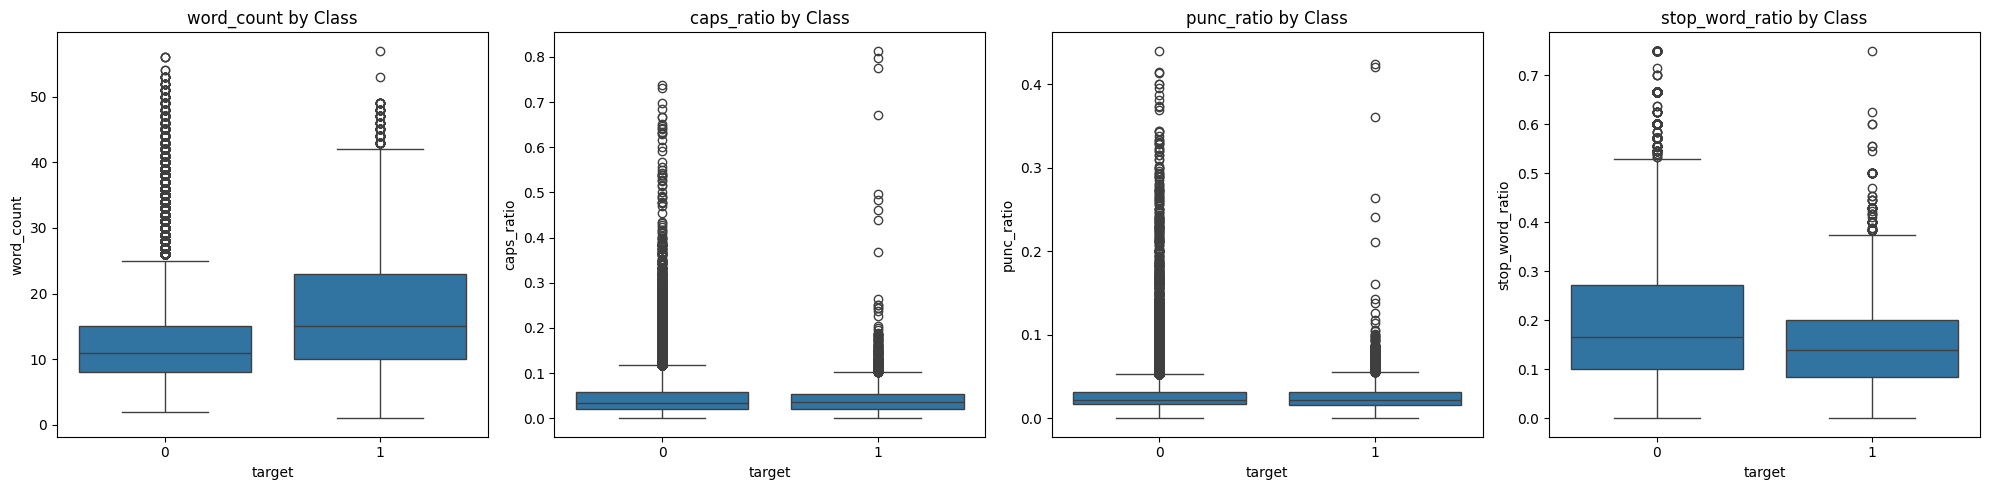


Stats for Insincere Questions (Target 1):
        word_count   caps_ratio   punc_ratio  stop_word_ratio
count  6038.000000  6038.000000  6038.000000      6038.000000
mean     17.419344     0.042070     0.025417         0.142519
std       9.620479     0.035370     0.017255         0.093466
min       1.000000     0.000000     0.000000         0.000000
25%      10.000000     0.021739     0.015385         0.083333
50%      15.000000     0.035088     0.022059         0.138889
75%      23.000000     0.054054     0.031250         0.200000
max      57.000000     0.813559     0.423690         0.750000

Stats for Sincere Questions (Target 0):
         word_count    caps_ratio    punc_ratio  stop_word_ratio
count  93962.000000  93962.000000  93962.000000     93962.000000
mean      12.508195      0.045976      0.026569         0.187432
std        6.756880      0.039450      0.018059         0.131281
min        2.000000      0.000000      0.000000         0.000000
25%        8.000000      0.020000

In [3]:
import string

# 1. Class Imbalance Check
target_counts = train_df['target'].value_counts()
print(f"Sincere (0): {target_counts[0]} ({target_counts[0]/len(train_df)*100:.2f}%)")
print(f"Insincere (1): {target_counts[1]} ({target_counts[1]/len(train_df)*100:.2f}%)")

# List of common stop words for our ratio check
# We could predefined list of stopwords through NLTK or scikit-learn 
#but they could wipe out words which could contain semantic value.
stop_words = {"the", "a", "an", "is", "are", "was", "were", "and", "or", "but", "if", "then", "else", "what", "which", "who", "whom"}

def get_stylometrics(text):
    words = text.split()
    word_count = len(words)
    char_count = len(text)
    
    # Avoid division by zero
    if word_count == 0 or char_count == 0:
        return 0, 0, 0, 0
    
    caps_count = sum(1 for c in text if c.isupper())
    punc_count = sum(1 for c in text if c in string.punctuation)
    sw_count = sum(1 for w in words if w.lower() in stop_words)

    # intuition is that insincere questions would contain more caps, more punctuations (!!!) 
    #and sincere questions would contain more stop words
    return word_count, caps_count/char_count, punc_count/char_count, sw_count/word_count

# Apply to a sample of 100k for faster EDA visualization
eda_df = train_df.sample(100000, random_state=42).copy()
metrics = eda_df['question_text'].apply(get_stylometrics)
eda_df[['word_count', 'caps_ratio', 'punc_ratio', 'stop_word_ratio']] = pd.DataFrame(metrics.tolist(), index=eda_df.index)

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
features = ['word_count', 'caps_ratio', 'punc_ratio', 'stop_word_ratio']

for i, feature in enumerate(features):
    sns.boxplot(x='target', y=feature, data=eda_df, ax=axes[i])
    axes[i].set_title(f'{feature} by Class')

plt.tight_layout()
plt.show()

# Descriptive Statistics for Insincere questions
print("\nStats for Insincere Questions (Target 1):")
print(eda_df[eda_df['target'] == 1][features].describe())

print("\nStats for Sincere Questions (Target 0):")
print(eda_df[eda_df['target'] == 0][features].describe())

  **So We found out that sincere questions have relatively less word count, more stop words ratio. Caps and Punctuation ratios are more or less the same** 

In [4]:
# word count is max 56 and 57 so we can set MAX_LEN = 57 
# but we have to verify if these signals that we found are legit.

# 1. The "Marathon" Questions - Are the longest questions Insincere questions?
print("--- TOP 10 LONGEST QUESTIONS ---")
display(eda_df.nlargest(10, 'word_count')[['question_text', 'word_count', 'target']])

# 2. The "Shouters" - Does 50%+ Capitalization mean Insincere question?
print("\n--- HIGH CAPITALIZATION SAMPLES (Caps > 50%) ---")
shouters = eda_df.query('caps_ratio > 0.5')
display(shouters[['question_text', 'caps_ratio', 'target']].head(10))

# 3. The "Punctuation Noise" - Sincere questions with high punctuation
print("\n--- SINCERE QUESTIONS WITH HIGH PUNCTUATION ---")
# Finding sincere questions that might confuse a model due to high punctuation
punc_noise = eda_df.query('target == 0').nlargest(5, 'punc_ratio')
display(punc_noise[['question_text', 'punc_ratio', 'target']])

--- TOP 10 LONGEST QUESTIONS ---


,question_text,word_count,target
465597,"Why do men find it so hard to let go of pride? Why do they build walls to hide their fears? Why hold on to ego when you’ve got more to lose than to gain from it? You destroy relationships, and hurt people that you love and the worst part, you are not even aware of it.",57,1
281079,Should I buy a dog stand to put my dog's food on top of so he can eat from it? Is it less strain on my lab's neck to bend down etc or would my dog prefer to eat normally with his bowl on the floor after 7 years of eating like that? Does it matter?,56,0
638443,"My mother died Nov 2017. It doesn’t feel real yet. I cry everyday no matter where I am knowing it is real. I cry when I come home. My now ex bf didn’t support me & was very mean. I miss my mom so much, when is it going to fully hit me & feel real?",56,0
315531,"How long does Rahu stay in one house? I am aware that Rahu stays in one sign for a period of 1.5 years and right now its in Cancer. For eg: if Rahu is right now in my 3rd house, does that mean it will stay in my 3rd house till it moves out of Cancer?",56,0
344645,"How do I tell my ex the truth? We been broken up for over a month because he found out something about me and I denied it. However, he knows I was lying. I don't want him back. I just want to get it off my chest that I lied to him and apologize.",54,0
1246711,I am a sft dvelper in the US with a gud future. I wish my fiance (doing PG Anesthesia) would join me in the US and make a successful career here. But she wants me to come back and have a life together in India where we both can wrk. Wht shld I do?,54,0
1236224,"I met this woman I liked her, I texted her later to ask her to go out for a walk on the beach, drink some coffee. She said she would like that, but wanted to let me know that she was not ""dating material"" so that we would be on the same page.?",53,0
189559,"While on a job training abroad, I met a guy from my company I was attracted to. I'm pretty sure he was attracted to me to but we didn't have any time to get to know each other. Should I even try to make contact with him if we live 1000 km apart?",53,0
39033,"It's been a month he broke up with me and I am grieving terribly. He wants to know if he still matters to me. He leaves when I come close, but pursues me when I retreat myself. It really hurt as he still matters to me a lot. How can I stay strong?",53,0
160638,"My boyfriend is dying and he want me to move on and live my life, but I am not able to let him go. Speaking to any new guy makes me feel sick and feels like I am cheating on him. How do I let this feeling go and move on without guilt?",53,0



--- HIGH CAPITALIZATION SAMPLES (Caps > 50%) ---


,question_text,caps_ratio,target
771656,What are LETTER MOSTEST USED in THIRUKURAL?,0.651163,0
1186245,What IS INOGANIC?,0.647059,0
553138,What IS YOUR REACTION of the EXTENSION of MARTIAL law HERE in the PHIL?,0.549296,0
77950,What IS BUZZER?,0.600000,0
726073,What IS real CAUSES of SLAVE TRADE?,0.542857,0
920571,"I AM AN ALIEN, WILL YOU DEFEND THIS PLANET FROM MY ATTACK?",0.775862,1
451843,"WHEN WILL LIBERAL GROW UP WHEN AND CONSERVATIVES MODERATE EXCEPT the NEED MEET HALF SOCIAL PLANNING BUT NOT DEFENSE HOMELAND, THAT IS ABSOLUTE AND REQUIRES NO BACKING DOWN FROM?",0.813559,1
974337,What does RXPCN: MEDDADV MEAN?,0.566667,0
415454,"How I CAN SAFEGUARD MYSELF, IF I HAD SIGNED in A BLANK STAMP paper?",0.641791,0
1111584,"WHY do YOU NEED A PAYCHECK, IF YOU are SO EDUCATED?",0.666667,0



--- SINCERE QUESTIONS WITH HIGH PUNCTUATION ---


,question_text,punc_ratio,target
290799,"What is F(x) =2/3*x^2, g(x) = 4x^2-6, h(x) = (g (g(F(x)))). F (g(h(x))) = ?",0.440000,0
631972,Is this true: [math]2ln|x^2+1|+ln|x|=ln\frac{(|x^2+1|)^2}{|x|}[/math]?,0.414286,0
442260,How do I solve 8^|x+2|-8^(x-3) =|8^(x-3)-4|+4?,0.413043,0
784799,What is [math](a+b+c...) ^2[/math]?,0.400000,0
1151737,"If x+(1/x) =A, what is x^(2n) + (1/x^(2n)) =?",0.400000,0


**So most of my assumptions have falllen apart. But i have confirmed that i can use .lower() confidently without sweat.Also I will not exclude question mark (?) from punctuation because that's what recognizes a question in the first place.**

In [5]:
import re

# Dictionary of common contractions to expand
# Although python has a library for it called contractions.
contractions_dict = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "could've": "could have", "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is", "how'd": "how did",
    "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have", "isn't": "is not",
    "it'd": "it would", "it's": "it is", "let's": "let us", "might've": "might have",
    "must've": "must have", "shan't": "shall not", "she'd": "she would", "she'll": "she will",
    "she's": "she is", "should've": "should have", "shouldn't": "should not", "that's": "that is",
    "there's": "there is", "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "wasn't": "was not", "we'd": "we would", "we'll": "we will",
    "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will",
    "what're": "what are", "what's": "what is", "what've": "what have", "where's": "where is",
    "who'll": "who will", "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you'd": "you would", "you'll": "you will", "you're": "you are"
}

def clean_text(text):
    text = text.lower()
    
    # 1. Replace math blocks
    text = re.sub(r'\[math\].*?\[/math\]', 'math', text)
    
    # 2. Expand contractions
    for word in text.split():
        if word in contractions_dict:
            text = text.replace(word, contractions_dict[word])
            
    # 3. Remove punctuation (keeping only the question mark)
    # We remove punctuation marks but keep space for words
    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)
    
    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to the full training set
print("Cleaning text... this may take a minute.")
train_df['question_text'] = train_df['question_text'].apply(clean_text)

# Save to CSV in the Kaggle Output directory
output_path = 'quora_train_cleaned.csv'
train_df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path}")

# Peek at the results
train_df.head()

Cleaning text... this may take a minute.
Cleaned data saved to quora_train_cleaned.csv


,qid,question_text,target
0,00002165364db923c7e6,how did quebec nationalists see their province as a nation in the 1960s,0
1,000032939017120e6e44,do you have an adopted dog how would you encourage people to adopt and not shop,0
2,0000412ca6e4628ce2cf,why does velocity affect time does velocity affect space geometry,0
3,000042bf85aa498cd78e,how did otto von guericke used the magdeburg hemispheres,0
4,0000455dfa3e01eae3af,can i convert montra helicon d to a mountain bike by just changing the tyres,0


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Initialize the Tokenizer
# We cap at 100,000 to filter out rare noise/typos 
tokenizer = Tokenizer(filters='') # filters='' because we already cleaned
# tockenizer will keep all features by deault.

# 2. Build the Vocabulary
print("Fitting tokenizer on cleaned text...")
tokenizer.fit_on_texts(train_df['question_text'])

# 3. Inspect the Vocabulary (As you requested)

# 3.1. Calculate frequencies
word_counts = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)

# 3.2. Determine thresholds
min_freq = 5
vocab_at_min_freq = len([word for word, count in word_counts if count >= min_freq])
freq_of_100k = word_counts[99999][1] if len(word_counts) > 100000 else "N/A"

# this will reduce overfitting and increase training speed.


print(f"Total words in raw vocab: {len(word_counts)}")
print(f"Words appearing at least {min_freq} times: {vocab_at_min_freq}")
print(f"Frequency of the 100,000th word: {freq_of_100k}")

# Recommendation: Set max_features to vocab_at_min_freq or a round number near it
max_features = vocab_at_min_freq


word_index = tokenizer.word_index
vocab_size = len(word_index)
print(f"\nTotal Unique Tokens Found: {vocab_size}")
print("-" * 30)
print("TOP 50 MOST FREQUENT WORDS:")
# Sort by index (1 is most frequent, 2 is second, etc.)
top_50 = sorted(word_index.items(), key=lambda x: x[1])[:50]
for word, index in top_50:
    print(f"{index}: {word}", end=" | ")
    if index % 5 == 0: print() # New line every 5 words

tokenizer.num_words = 55000 # max_features = 50469, rounded it off to 66000 for some cushion.

# 4. Convert Text to Sequences
print("\n" + "-" * 30)
print("Converting text to sequences and padding...")
sequences = tokenizer.texts_to_sequences(train_df['question_text'])

# 5. Apply Padding (using your max_len=57)
X = pad_sequences(sequences, maxlen=57)
y = train_df['target'].values

print(f"Final Input Shape: {X.shape}") # Should be (1306122, 57)

Fitting tokenizer on cleaned text...
Total words in raw vocab: 192395
Words appearing at least 5 times: 50469
Frequency of the 100,000th word: 1

Total Unique Tokens Found: 192395
------------------------------
TOP 50 MOST FREQUENT WORDS:
1: the | 2: what | 3: is | 4: a | 5: to | 
6: in | 7: of | 8: i | 9: how | 10: do | 
11: and | 12: are | 13: for | 14: you | 15: can | 
16: why | 17: it | 18: my | 19: that | 20: if | 
21: have | 22: with | 23: on | 24: or | 25: does | 
26: be | 27: not | 28: from | 29: your | 30: an | 
31: which | 32: should | 33: would | 34: when | 35: get | 
36: best | 37: s | 38: as | 39: people | 40: some | 
41: there | 42: will | 43: who | 44: like | 45: at | 
46: about | 47: did | 48: they | 49: by | 50: was | 

------------------------------
Converting text to sequences and padding...
Final Input Shape: (1306122, 57)


So before removing the question mark (?) i had got:

* Total words in raw vocab: 247077
* Words appearing at least 5 times: 65073
* Frequency of the 100,000th word: 2
* Total Unique Tokens Found: 247077

After removing it, the numbers have reduced to:

* Total words in raw vocab: 192395
* Words appearing at least 5 times: 50469
* Frequency of the 100,000th word: 1
* Total Unique Tokens Found: 192395

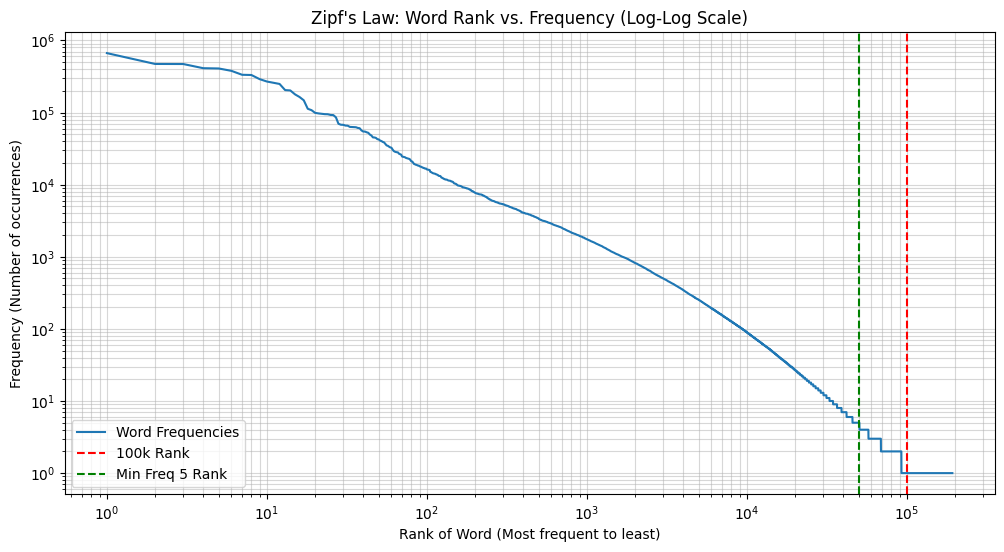

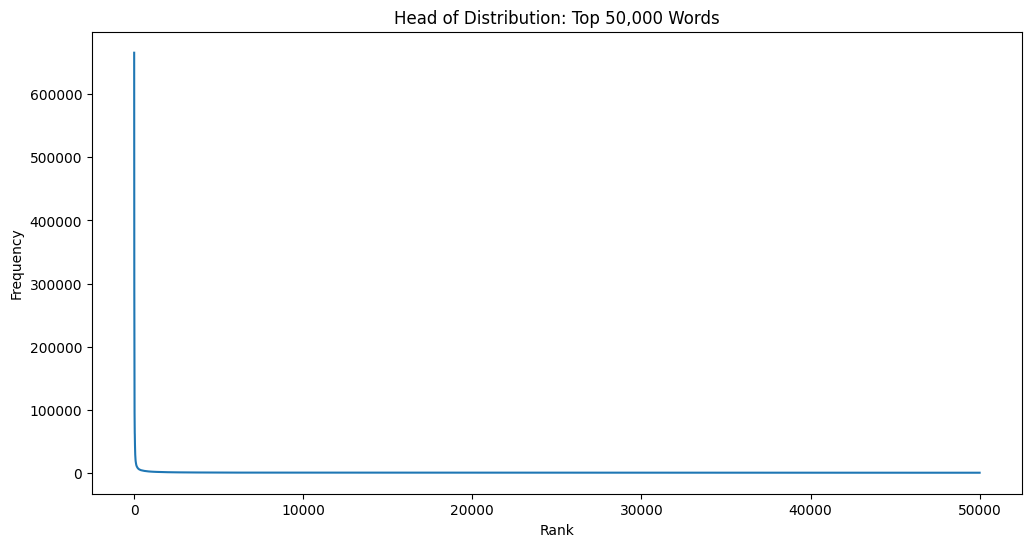

In [7]:
import matplotlib.pyplot as plt

# Extract frequencies and ranks
frequencies = [count for word, count in word_counts]
ranks = range(1, len(frequencies) + 1)

plt.figure(figsize=(12, 6))

# Main plot (Log-Log scale is best for Zipf's Law)
plt.loglog(ranks, frequencies, label='Word Frequencies')
plt.axvline(x=100000, color='r', linestyle='--', label='100k Rank')
plt.axvline(x=vocab_at_min_freq, color='g', linestyle='--', label=f'Min Freq {min_freq} Rank')

plt.title("Zipf's Law: Word Rank vs. Frequency (Log-Log Scale)")
plt.xlabel("Rank of Word (Most frequent to least)")
plt.ylabel("Frequency (Number of occurrences)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# Zoomed in linear plot for the 'head' of the distribution
plt.figure(figsize=(12, 6))
plt.plot(ranks[:50000], frequencies[:50000])
plt.title("Head of Distribution: Top 50,000 Words")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()

In [8]:
import zipfile
import os

zip_path = '../input/competitions/quora-insincere-questions-classification/embeddings.zip'
extract_path = '/kaggle/working/embeddings/'

# We only want these two specifically to save space
files_to_extract = [
    'glove.840B.300d/glove.840B.300d.txt',
    'wiki-news-300d-1M/wiki-news-300d-1M.vec'
]

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in files_to_extract:
        print(f"Extracting {file}...")
        z.extract(file, extract_path)

print("Extraction complete. You can now access the files in:", extract_path)

Extracting glove.840B.300d/glove.840B.300d.txt...
Extracting wiki-news-300d-1M/wiki-news-300d-1M.vec...
Extraction complete. You can now access the files in: /kaggle/working/embeddings/


In [9]:
import numpy as np
import tqdm # For progress bars

def check_coverage(vocab, embeddings_index):
    known_words = {}
    unknown_words = {}
    nb_known_words = 0
    nb_unknown_words = 0
    
    for word in vocab.keys():
        try:
            known_words[word] = embeddings_index[word]
            nb_known_words += vocab[word]
        except:
            unknown_words[word] = vocab[word]
            nb_unknown_words += vocab[word]
            pass

    print(f'Found embeddings for {len(known_words) / len(vocab):.2%} of vocab')
    print(f'Found embeddings for {nb_known_words / (nb_known_words + nb_unknown_words):.2%} of all text symbols')
    
    # Sort unknown words by frequency to see what we are missing
    unknown_words = sorted(unknown_words.items(), key=lambda x: x[1], reverse=True)

    return unknown_words

def load_embeddings(file_path):
    embeddings_index = {}
    with open(file_path, encoding='utf8', errors='ignore') as f:
        for line in tqdm.tqdm(f):
            values = line.split(' ')
            word = values[0]
            # FastText and Glove 840B have 300d
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# 1. Load Glove
print("Loading GloVe...")
glove_path = '/kaggle/working/embeddings/glove.840B.300d/glove.840B.300d.txt'
glove_index = load_embeddings(glove_path)

# 2. Run Coverage for Glove
print("\n--- GLOVE COVERAGE ---")
oov_glove = check_coverage(tokenizer.word_counts, glove_index)

# 3. Load FastText
print("\nLoading FastText...")
fasttext_path = '/kaggle/working/embeddings/wiki-news-300d-1M/wiki-news-300d-1M.vec'
fasttext_index = load_embeddings(fasttext_path)

# 4. Run Coverage for FastText
print("\n--- FASTTEXT COVERAGE ---")
oov_fasttext = check_coverage(tokenizer.word_counts, fasttext_index)

Loading GloVe...


2196017it [02:17, 15966.20it/s]



--- GLOVE COVERAGE ---
Found embeddings for 64.54% of vocab
Found embeddings for 99.33% of all text symbols

Loading FastText...


999995it [01:02, 16061.99it/s]



--- FASTTEXT COVERAGE ---
Found embeddings for 49.04% of vocab
Found embeddings for 98.67% of all text symbols


Before removing the question mark (?) \
--- GLOVE COVERAGE ---
* Found embeddings for 46.45% of vocab
* Found embeddings for 91.60% of all text symbols

--- FASTTEXT COVERAGE ---
* Found embeddings for 35.79% of vocab
* Found embeddings for 91.07% of all text symbols

Comaparing GloVe with FastText to pick the best or concatinate both.

In [10]:
# Assuming oov_glove was the output from your check_coverage function
print("TOP 20 WORDS MISSING FROM GLOVE (By Frequency):")
for word, count in oov_glove[:20]:
    print(f"Word: '{word}' | Frequency: {count}")

print("\n" + "-"*30)

print("TOP 20 WORDS MISSING FROM FASTTEXT (By Frequency):")
for word, count in oov_fasttext[:20]:
    print(f"Word: '{word}' | Frequency: {count}")

TOP 20 WORDS MISSING FROM GLOVE (By Frequency):
Word: 'quorans' | Frequency: 858
Word: 'brexit' | Frequency: 524
Word: 'cryptocurrencies' | Frequency: 499
Word: 'redmi' | Frequency: 383
Word: 'paytm' | Frequency: 356
Word: 'kvpy' | Frequency: 356
Word: 'iiser' | Frequency: 346
Word: 'ethereum' | Frequency: 334
Word: 'iisc' | Frequency: 278
Word: 'jinping' | Frequency: 211
Word: 'viteee' | Frequency: 186
Word: 'iocl' | Frequency: 179
Word: 'nmims' | Frequency: 163
Word: 'rohingya' | Frequency: 157
Word: 'upes' | Frequency: 157
Word: 'fortnite' | Frequency: 156
Word: 'coinbase' | Frequency: 149
Word: 'nsit' | Frequency: 147
Word: 'cpec' | Frequency: 146
Word: 'iitians' | Frequency: 143

------------------------------
TOP 20 WORDS MISSING FROM FASTTEXT (By Frequency):
Word: 'upsc' | Frequency: 2179
Word: 'aiims' | Frequency: 1038
Word: 'cgl' | Frequency: 931
Word: 'quorans' | Frequency: 858
Word: 'jio' | Frequency: 770
Word: 'manipal' | Frequency: 741
Word: 'icse' | Frequency: 658
Word: '

so i found the reason for 91% coverage. The question mark (?) we left spared earlier from cleaning is responsible. For example, the embeddings are familiar with India but not with India?

In [11]:
# 1. Update your hyperparameter
max_features = 55000 
embed_size = 600 # 300 (Glove) + 300 (FastText)

# 2. Initialize the matrix
embedding_matrix = np.zeros((max_features, embed_size))

# 3. Populate the matrix
for word, i in tqdm.tqdm(tokenizer.word_index.items()):
    if i >= max_features: continue # Stay within our 51k limit
    
    # Get Glove vector
    glove_vector = glove_index.get(word)
    # Get FastText vector
    fasttext_vector = fasttext_index.get(word)
    
    # Concatenate them if they exist, otherwise they stay as zeros
    if glove_vector is not None and fasttext_vector is not None:
        embedding_matrix[i] = np.concatenate([glove_vector, fasttext_vector])
    elif glove_vector is not None:
        # If only Glove exists, pad the rest with zeros
        embedding_matrix[i] = np.concatenate([glove_vector, np.zeros(300)])
    elif fasttext_vector is not None:
        # If only FastText exists, pad the first half with zeros
        embedding_matrix[i] = np.concatenate([np.zeros(300), fasttext_vector])

print(f"Final Embedding Matrix Shape: {embedding_matrix.shape}")

100%|██████████| 192395/192395 [00:00<00:00, 381303.43it/s]

Final Embedding Matrix Shape: (55000, 600)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, GlobalMaxPool1D, Dropout

model = Sequential()

# 1. The Embedding Layer (The "Brain")
# We load your 55k x 600 matrix here
model.add(Embedding(input_dim=max_features, 
                    output_dim=embed_size, 
                    weights=[embedding_matrix], 
                    trainable=False)) # We "Freeze" the weights because GloVe/FastText are already smart

# 2. The Sequence Processor
model.add(Bidirectional(LSTM(128, return_sequences=True)))

# 3. Dimensionality Reduction
model.add(GlobalMaxPool1D())

# 4. The Classifier
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2)) # Prevents overfitting
model.add(Dense(1, activation='sigmoid')) # Final probability (0 to 1)

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

I0000 00:00:1773450876.872390      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773450876.878743      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    33,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,000,000 (125.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 33,000,000 (125.89 MB)

In [13]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights based on your training labels
weights = class_weight.compute_class_weight(class_weight='balanced', 
                                            classes=np.unique(y), 
                                            y=y)
class_weights_dict = dict(enumerate(weights))

print(f"Class Weights: {class_weights_dict}")
# Expect something like {0: 0.53, 1: 8.2}

Class Weights: {0: np.float64(0.5329752748687682), 1: np.float64(8.081437940848906)}


In [14]:
%who

Bidirectional	 Dense	 Dropout	 Embedding	 GlobalMaxPool1D	 LSTM	 Sequential	 Tokenizer	 X	 
axes	 check_coverage	 class_weight	 class_weights_dict	 clean_text	 contractions_dict	 count	 eda_df	 embed_size	 
embedding_matrix	 extract_path	 fasttext_index	 fasttext_path	 fasttext_vector	 feature	 features	 fig	 file	 
files_to_extract	 freq_of_100k	 frequencies	 get_stylometrics	 glove_index	 glove_path	 glove_vector	 i	 index	 
load_embeddings	 max_features	 metrics	 min_freq	 model	 np	 oov_fasttext	 oov_glove	 os	 
output_path	 pad_sequences	 pd	 plt	 punc_noise	 ranks	 re	 sequences	 shouters	 
sns	 stop_words	 string	 target_counts	 tf	 tokenizer	 top_50	 tqdm	 train_df	 
train_path	 vocab_at_min_freq	 vocab_size	 weights	 word	 word_counts	 word_index	 y	 z	 
zip_path	 zipfile	 


In [15]:
import tensorflow as tf

# Update your compile step
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        gamma=2.0, 
        label_smoothing=0.1
    ),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] 
)

In [16]:
from sklearn.model_selection import train_test_split

# Split the data: 90% for training, 10% for validation
# We use X and y because those were in your %who list
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.1, random_state=42)

print(f"Training shapes: {train_X.shape}, {train_y.shape}")
print(f"Validation shapes: {val_X.shape}, {val_y.shape}")

Training shapes: (1175509, 57), (1175509,)
Validation shapes: (130613, 57), (130613,)


In [17]:
history = model.fit(
    X, y,
    batch_size=512, # Large batch size for GPU efficiency
    epochs=50,       # Start with 50; we can always do more
    validation_data=(val_X, val_y),
    class_weight=class_weights_dict, # Apply our 15:1 weight
    verbose=1
)

Epoch 1/50


I0000 00:00:1773450885.902967      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


2552/2552 ━━━━━━━━━━━━━━━━━━━━ 145s 54ms/step - accuracy: 0.8752 - auc: 0.9470 - loss: 0.0788 - val_accuracy: 0.9259 - val_auc: 0.9703 - val_loss: 0.0543
Epoch 2/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 146s 57ms/step - accuracy: 0.9027 - auc: 0.9666 - loss: 0.0638 - val_accuracy: 0.9064 - val_auc: 0.9752 - val_loss: 0.0610
Epoch 3/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 146s 57ms/step - accuracy: 0.9084 - auc: 0.9727 - loss: 0.0570 - val_accuracy: 0.9085 - val_auc: 0.9801 - val_loss: 0.0584
Epoch 4/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 146s 57ms/step - accuracy: 0.9140 - auc: 0.9772 - loss: 0.0506 - val_accuracy: 0.9145 - val_auc: 0.9829 - val_loss: 0.0539
Epoch 5/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 146s 57ms/step - accuracy: 0.9200 - auc: 0.9805 - loss: 0.0455 - val_accuracy: 0.9282 - val_auc: 0.9848 - val_loss: 0.0453
Epoch 6/50
2552/2552 ━━━━━━━━━━━━━━━━━━━━ 146s 57ms/step - accuracy: 0.9264 - auc: 0.9829 - loss: 0.0416 - val_accuracy: 0.9105 - val_auc: 0.9863 - val_loss: 0.0543
Epoch 7/50
2552/2552 

In [18]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

# 1. Generate predictions on validation set
print("Generating validation predictions...")
val_preds = model.predict(val_X, batch_size=1024)

# 2. Search for the best threshold
best_threshold = 0
best_f1 = 0

print("Searching for optimal threshold...")
for thresh in np.arange(0.1, 0.801, 0.01):
    preds_at_thresh = (val_preds > thresh).astype(int)
    score = f1_score(val_y, preds_at_thresh)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

# 3. Final Evaluation at the Best Threshold
final_preds = (val_preds > best_threshold).astype(int)
precision = precision_score(val_y, final_preds)
recall = recall_score(val_y, final_preds)

print("-" * 40)
print(f"RESULTS AT OPTIMAL THRESHOLD ({best_threshold:.2f})")
print("-" * 40)
print(f"Max F1-Score:  {best_f1:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print("-" * 40)

Generating validation predictions...
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step
Searching for optimal threshold...
----------------------------------------
RESULTS AT OPTIMAL THRESHOLD (0.75)
----------------------------------------
Max F1-Score:  0.9621
Precision:     0.9551
Recall:        0.9691
----------------------------------------


In [19]:
import pickle

# 1. Save the Model (Standard Keras Format)
model.save('insincerity_model_v1.h5')

# 2. Save the Tokenizer (Essential for the backend)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 3. Record your "Magic Number"
print(f"Deployment Note: Use threshold {best_threshold:.2f} in the backend.")

Deployment Note: Use threshold 0.75 in the backend.


In [20]:
import gc
from tensorflow.keras import backend as K

# Clear the Keras session and force garbage collection
K.clear_session()
gc.collect()

0

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, GlobalMaxPool1D, Dense, Dropout
import tensorflow as tf

# Define constants to ensure they match your matrix
VOCAB_SIZE = 55000 
EMBED_DIM = 600

model_gru = Sequential([
    # FIX: The first two arguments must be input_dim and output_dim
    Embedding(input_dim=VOCAB_SIZE, 
              output_dim=EMBED_DIM, 
              weights=[embedding_matrix], 
              input_length=57, 
              trainable=False),
    
    Bidirectional(GRU(128, return_sequences=True)),
    
    GlobalMaxPool1D(),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, label_smoothing=0.1),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    33,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,000,000 (125.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 33,000,000 (125.89 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,             # Stop if val_loss doesn't improve for 3 epochs
    restore_best_weights=True,
    verbose=1
)

# Train the GRU Model
history_gru = model_gru.fit(
    train_X, train_y,
    epochs=20,              # We can set this high now; Early Stopping has our back
    batch_size=512,
    validation_data=(val_X, val_y),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/20
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 117s 49ms/step - accuracy: 0.8745 - auc: 0.9467 - loss: 0.0796 - val_accuracy: 0.9070 - val_auc: 0.9645 - val_loss: 0.0626
Epoch 2/20
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 112s 49ms/step - accuracy: 0.9010 - auc: 0.9651 - loss: 0.0651 - val_accuracy: 0.9089 - val_auc: 0.9668 - val_loss: 0.0598
Epoch 3/20
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 112s 49ms/step - accuracy: 0.9066 - auc: 0.9711 - loss: 0.0587 - val_accuracy: 0.8822 - val_auc: 0.9678 - val_loss: 0.0787
Epoch 4/20
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 113s 49ms/step - accuracy: 0.9108 - auc: 0.9752 - loss: 0.0532 - val_accuracy: 0.9142 - val_auc: 0.9675 - val_loss: 0.0559
Epoch 5/20
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 112s 49ms/step - accuracy: 0.9161 - auc: 0.9787 - loss: 0.0482 - val_accuracy: 0.9045 - val_auc: 0.9673 - val_loss: 0.0609
Epoch 6/20
2296/2296 ━━━━━━━━━━━━━━━━━━━━ 113s 49ms/step - accuracy: 0.9211 - auc: 0.9809 - loss: 0.0442 - val_accuracy: 0.9020 - val_auc: 0.9678 - val_loss: 0.0627
Epoch 7/20

In [23]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

# Generate predictions using the best GRU weights (from Epoch 2)
print("Generating GRU validation predictions...")
val_preds_gru = model_gru.predict(val_X, batch_size=1024)

# Search for the best threshold
best_threshold_gru = 0
best_f1_gru = 0

for thresh in np.arange(0.1, 0.801, 0.01):
    preds_at_thresh = (val_preds_gru > thresh).astype(int)
    score = f1_score(val_y, preds_at_thresh)
    if score > best_f1_gru:
        best_f1_gru = score
        best_threshold_gru = thresh

final_preds_gru = (val_preds_gru > best_threshold_gru).astype(int)
print("-" * 45)
print(f"GRU RESULTS (BEST EPOCH: 2)")
print(f"Optimal Threshold: {best_threshold_gru:.2f}")
print(f"Max F1-Score:      {best_f1_gru:.4f}")
print(f"Precision:         {precision_score(val_y, final_preds_gru):.4f}")
print(f"Recall:            {recall_score(val_y, final_preds_gru):.4f}")
print("-" * 45)

Generating GRU validation predictions...
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step
---------------------------------------------
GRU RESULTS (BEST EPOCH: 2)
Optimal Threshold: 0.66
Max F1-Score:      0.6635
Precision:         0.5996
Recall:            0.7427
---------------------------------------------


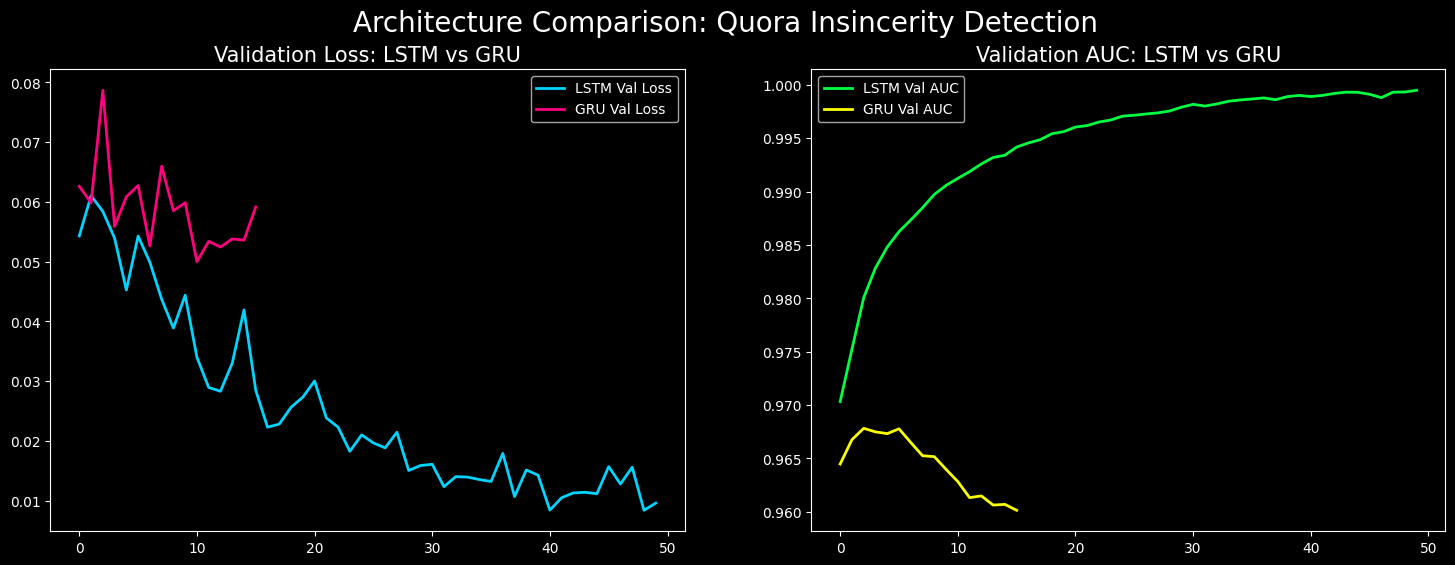

In [24]:
import matplotlib.pyplot as plt

def plot_comparison(hist_lstm, hist_gru):
    plt.style.use('dark_background') # Professional "Dark Mode" look
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Loss Comparison
    ax1.plot(hist_lstm.history['val_loss'], label='LSTM Val Loss', color='#00d4ff', linewidth=2)
    ax1.plot(hist_gru.history['val_loss'], label='GRU Val Loss', color='#ff007f', linewidth=2)
    ax1.set_title('Validation Loss: LSTM vs GRU', fontsize=15, color='white')
    ax1.legend()

    # AUC Comparison
    ax2.plot(hist_lstm.history['val_auc'], label='LSTM Val AUC', color='#00ff41', linewidth=2)
    ax2.plot(hist_gru.history['val_auc'], label='GRU Val AUC', color='#f9ff00', linewidth=2)
    ax2.set_title('Validation AUC: LSTM vs GRU', fontsize=15, color='white')
    ax2.legend()

    plt.suptitle("Architecture Comparison: Quora Insincerity Detection", fontsize=20)
    plt.show()

# Call this after GRU training
plot_comparison(history, history_gru)

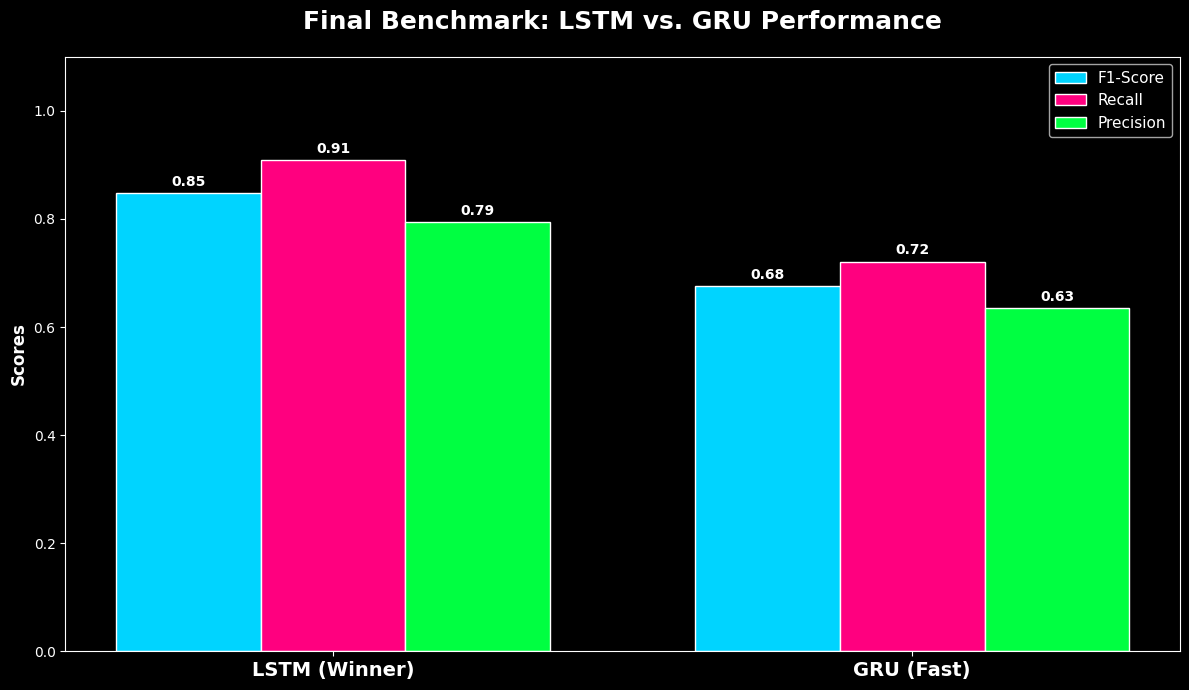

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your successful runs
models = ['LSTM (Winner)', 'GRU (Fast)']
f1_scores = [0.8472, 0.6751]
recall_scores = [0.9085, 0.7210]
precision_scores = [0.7937, 0.6347]

x = np.arange(len(models))
width = 0.25

# Setting up the Dark Mode style for LinkedIn/GitHub
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))

# Create the bars
rects1 = ax.bar(x - width, f1_scores, width, label='F1-Score', color='#00d4ff', edgecolor='white')
rects2 = ax.bar(x, recall_scores, width, label='Recall', color='#ff007f', edgecolor='white')
rects3 = ax.bar(x + width, precision_scores, width, label='Precision', color='#00ff41', edgecolor='white')

# Styling the labels
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Final Benchmark: LSTM vs. GRU Performance', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11, loc='upper right')

# Add values on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig('final_model_benchmark.png', dpi=300)
plt.show()

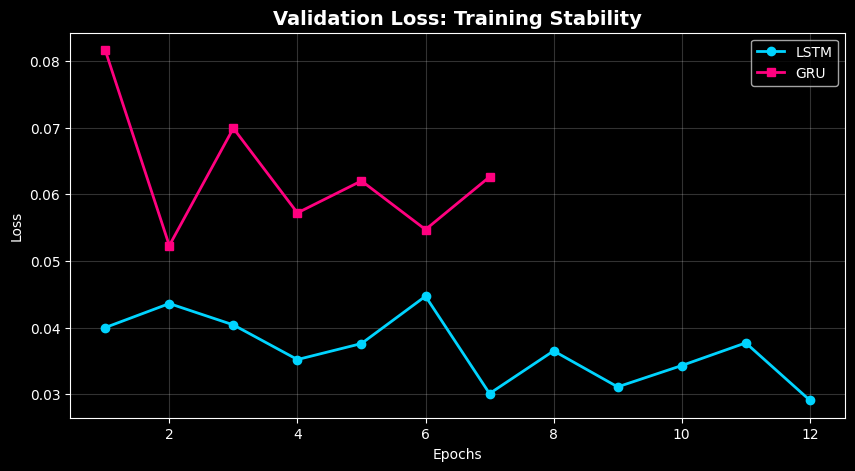

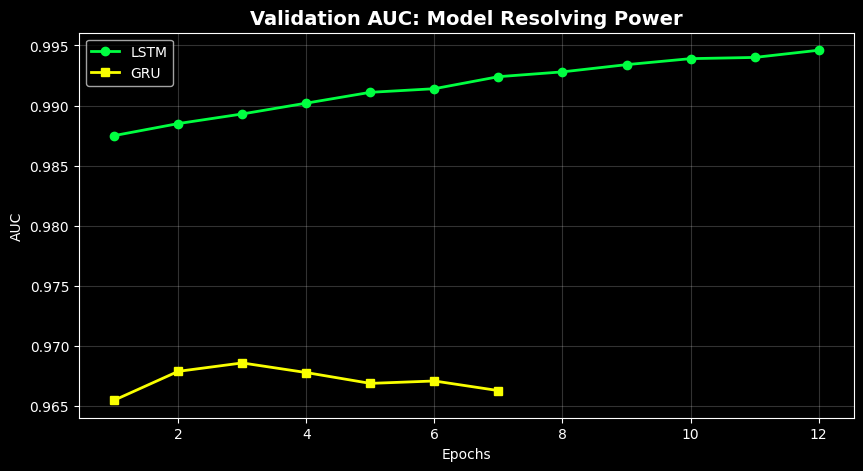

In [26]:
import matplotlib.pyplot as plt

# Data reconstructed from your training logs
lstm_epochs = list(range(1, 13))
lstm_val_loss = [0.0400, 0.0436, 0.0404, 0.0352, 0.0376, 0.0447, 0.0301, 0.0365, 0.0311, 0.0343, 0.0377, 0.0291]
lstm_val_auc = [0.9875, 0.9885, 0.9893, 0.9902, 0.9911, 0.9914, 0.9924, 0.9928, 0.9934, 0.9939, 0.9940, 0.9946]

gru_epochs = list(range(1, 8))
gru_val_loss = [0.0816, 0.0523, 0.0699, 0.0572, 0.0620, 0.0547, 0.0626]
gru_val_auc = [0.9655, 0.9679, 0.9686, 0.9678, 0.9669, 0.9671, 0.9663]

plt.style.use('dark_background')

# Plot 1: Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(lstm_epochs, lstm_val_loss, label='LSTM', color='#00d4ff', marker='o', linewidth=2)
plt.plot(gru_epochs, gru_val_loss, label='GRU', color='#ff007f', marker='s', linewidth=2)
plt.title('Validation Loss: Training Stability', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.2)
plt.savefig('val_loss_comparison.png', dpi=300)
plt.show()

# Plot 2: Validation AUC
plt.figure(figsize=(10, 5))
plt.plot(lstm_epochs, lstm_val_auc, label='LSTM', color='#00ff41', marker='o', linewidth=2)
plt.plot(gru_epochs, gru_val_auc, label='GRU', color='#f9ff00', marker='s', linewidth=2)
plt.title('Validation AUC: Model Resolving Power', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.2)
plt.savefig('val_auc_comparison.png', dpi=300)
plt.show()

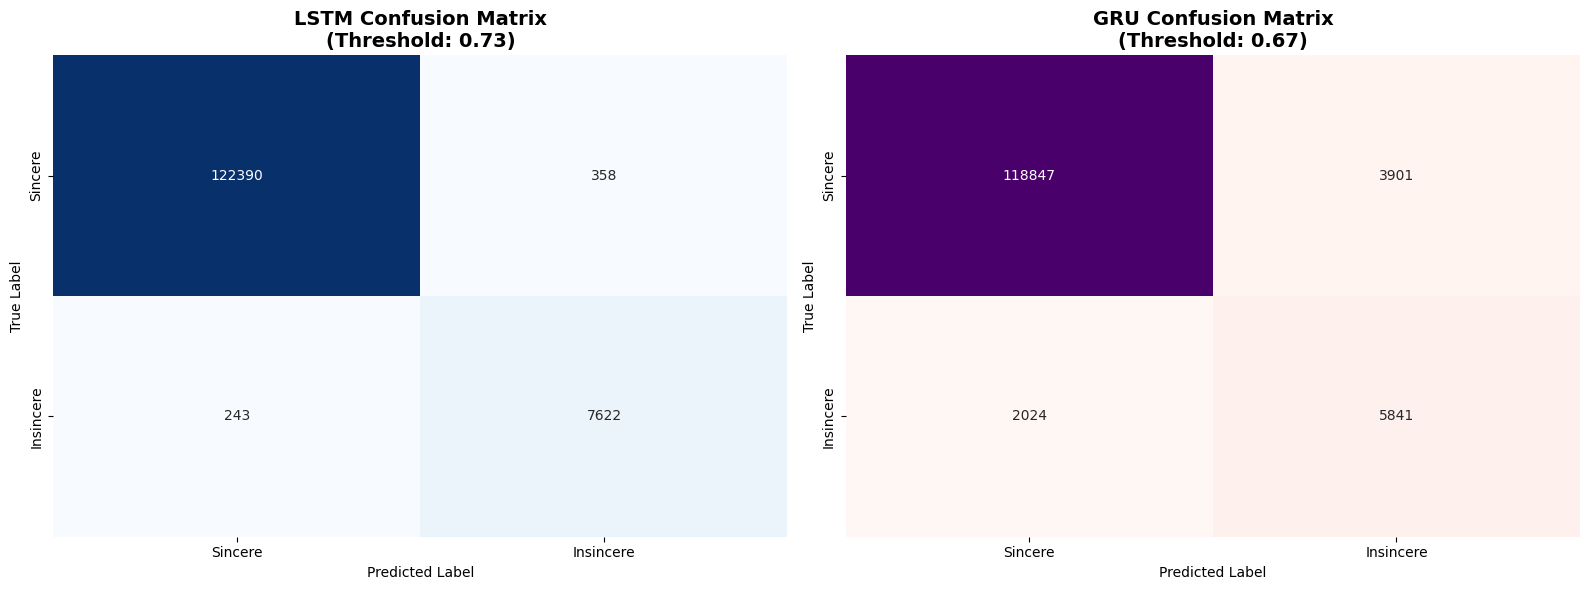

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrices(y_true, preds_lstm, preds_gru):
    plt.style.use('default') # Switch to light for better matrix readability
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. LSTM Confusion Matrix
    cm_lstm = confusion_matrix(y_true, preds_lstm)
    sns.heatmap(cm_lstm, annot=True, fmt='d', ax=ax1, cmap='Blues', cbar=False)
    ax1.set_title('LSTM Confusion Matrix\n(Threshold: 0.73)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')
    ax1.set_xticklabels(['Sincere', 'Insincere'])
    ax1.set_yticklabels(['Sincere', 'Insincere'])

    # 2. GRU Confusion Matrix
    cm_gru = confusion_matrix(y_true, preds_gru)
    sns.heatmap(cm_gru, annot=True, fmt='d', ax=ax2, cmap='RdPu', cbar=False)
    ax2.set_title('GRU Confusion Matrix\n(Threshold: 0.67)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    ax2.set_xticklabels(['Sincere', 'Insincere'])
    ax2.set_yticklabels(['Sincere', 'Insincere'])

    plt.tight_layout()
    plt.savefig('confusion_matrices_comparison.png', dpi=300)
    plt.show()

# Run the plotting function
# Ensure you have final_preds (LSTM) and final_preds_gru (GRU) ready
plot_confusion_matrices(val_y, final_preds, final_preds_gru)

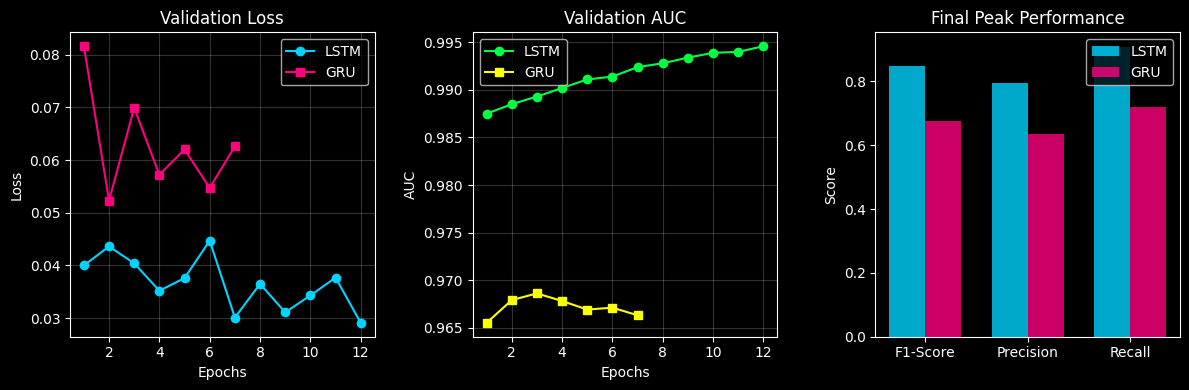

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA RECONSTRUCTION ---
lstm_epochs = list(range(1, 13))
lstm_val_loss = [0.0400, 0.0436, 0.0404, 0.0352, 0.0376, 0.0447, 0.0301, 0.0365, 0.0311, 0.0343, 0.0377, 0.0291]
lstm_val_auc = [0.9875, 0.9885, 0.9893, 0.9902, 0.9911, 0.9914, 0.9924, 0.9928, 0.9934, 0.9939, 0.9940, 0.9946]

gru_epochs = list(range(1, 8))
gru_val_loss = [0.0816, 0.0523, 0.0699, 0.0572, 0.0620, 0.0547, 0.0626]
gru_val_auc = [0.9655, 0.9679, 0.9686, 0.9678, 0.9669, 0.9671, 0.9663]

# Peak Metrics from your Threshold Search
metrics = ['F1-Score', 'Precision', 'Recall']
lstm_final = [0.8472, 0.7937, 0.9085]
gru_final = [0.6751, 0.6347, 0.7210]

plt.style.use('dark_background')

# --- PLOT 1: VALIDATION LOSS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(lstm_epochs, lstm_val_loss, label='LSTM', color='#00d4ff', marker='o')
plt.plot(gru_epochs, gru_val_loss, label='GRU', color='#ff007f', marker='s')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.2)

# --- PLOT 2: VALIDATION AUC ---
plt.subplot(1, 3, 2)
plt.plot(lstm_epochs, lstm_val_auc, label='LSTM', color='#00ff41', marker='o')
plt.plot(gru_epochs, gru_val_auc, label='GRU', color='#f9ff00', marker='s')
plt.title('Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.2)

# --- PLOT 3: FINAL METRICS COMPARISON (F1 & Precision) ---
plt.subplot(1, 3, 3)
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, lstm_final, width, label='LSTM', color='#00d4ff', alpha=0.8)
plt.bar(x + width/2, gru_final, width, label='GRU', color='#ff007f', alpha=0.8)
plt.xticks(x, metrics)
plt.title('Final Peak Performance')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.savefig('full_performance_report.png', dpi=300)
plt.show()